<a href="https://colab.research.google.com/github/AronJoseph96/AI-ML/blob/main/mnist_dense_neural_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


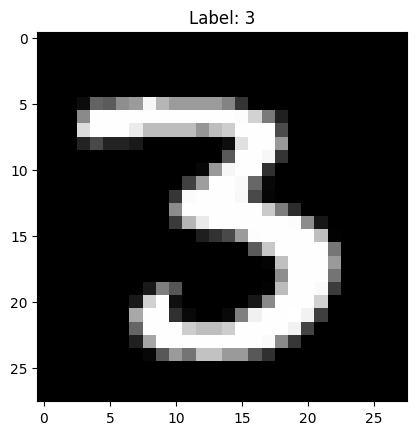

In [ ]:
plt.imshow(X_train[12], cmap='gray')
plt.title(f'Label: {y_train[12]}')
plt.show()

In [ ]:
#flatten
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

In [ ]:
#preprocessing
X_train = X_train/225.0
X_test = X_test/225.0

In [ ]:
#reshap
X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)

In [ ]:
#oneHotEncode
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test,10)

In [ ]:
#building model

model = keras.Sequential([
    keras.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),layers.Dropout(0.2),
    layers.Dense(64, activation='relu'), layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [ ]:
#training model

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8946 - loss: 0.3525 - val_accuracy: 0.9645 - val_loss: 0.1210
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9502 - loss: 0.1678 - val_accuracy: 0.9735 - val_loss: 0.0876
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9591 - loss: 0.1326 - val_accuracy: 0.9767 - val_loss: 0.0812
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9654 - loss: 0.1135 - val_accuracy: 0.9783 - val_loss: 0.0729
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9704 - loss: 0.0963 - val_accuracy: 0.9798 - val_loss: 0.0714
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9720 - loss: 0.0888 - val_accuracy: 0.9788 - val_loss: 0.0734
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9740 - loss: 0.0816 - val_accuracy: 0.9803 - val_loss: 0.0703
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9762 - loss: 0.0730 - 

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test Accuracy: 0, test_acc')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9790 - loss: 0.0734
Test Accuracy: 0, test_acc


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 967us/step


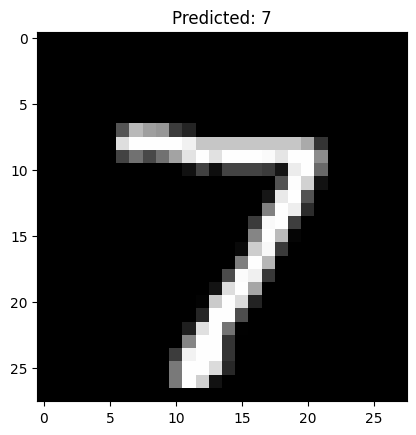

[8.8902444e-12 1.3372817e-08 6.6601285e-07 2.4327946e-05 5.7770344e-11
 6.7920376e-09 4.2630440e-14 9.9997455e-01 6.3321224e-08 2.4460832e-07]


In [ ]:
predictions = model.predict(X_test)

plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.title(f'Predicted: {np.argmax(predictions[0])}')
plt.show()
print(predictions[0])

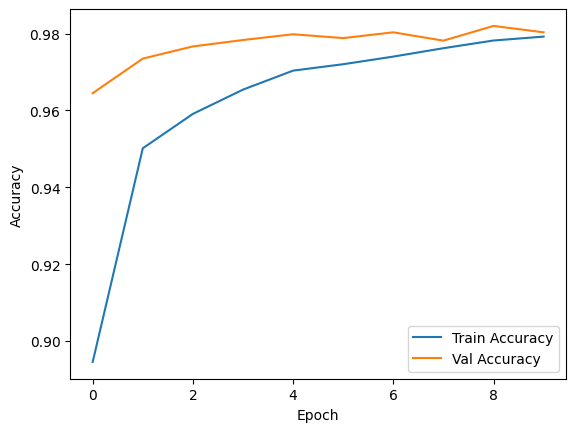

In [ ]:
#training history
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

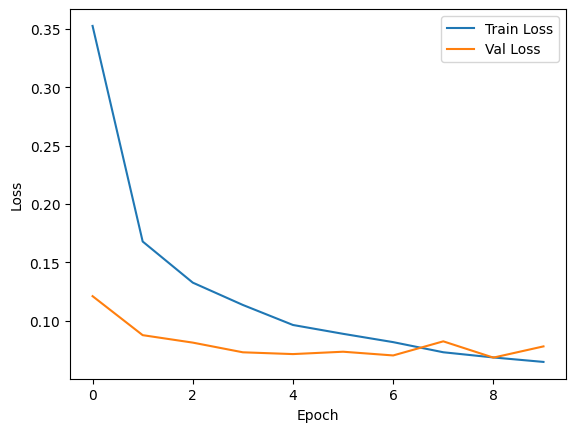

In [ ]:

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()